Dataset Shape: (569, 30)

Target Classes:
0 = Malignant
1 = Benign

Class Distribution:
1    357
0    212
dtype: int64

Training Data Shape: (455, 30)
Testing Data Shape: (114, 30)

LOGISTIC REGRESSION RESULTS

Confusion Matrix:
[[41  1]
 [ 1 71]]

Accuracy: 0.9824561403508771

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Confusion Matrix Interpretation:
True Negatives (TN): 41
False Positives (FP): 1
False Negatives (FN): 1
True Positives (TP): 71

METRIC INTERPRETATION

1. Precision:
   Precision measures how many predicted positive cases
   are actually positive.

2. Recall:
   Recall measures how many actual positive cases
   were correctly identified.

3. F1-Score:
   F1-score is 

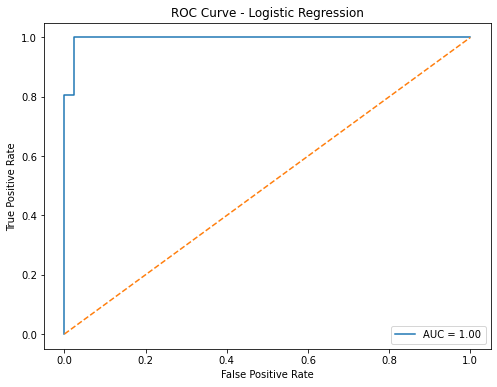


BALANCED LOGISTIC REGRESSION

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114


DECISION TREE CLASSIFIER

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.93      0.89        42
           1       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114


GRID SEARCH CV

Best Parameters:
{'C': 0.1, 'solver': 'lbfgs'}

Best Cross Validation Score:
0.9845246868091377

Classification Report of Best Model:
              precision    recall  f1-score   support

           0       0.98      0.95   

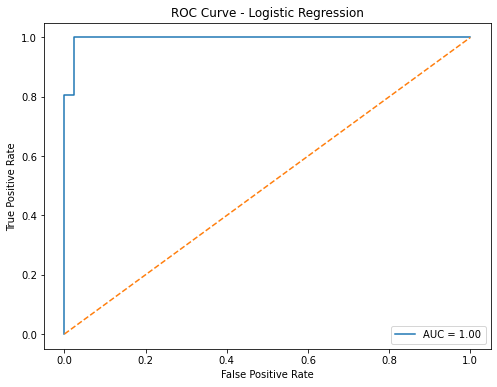


BALANCED LOGISTIC REGRESSION

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114


DECISION TREE CLASSIFIER

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.93      0.89        42
           1       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114


GRID SEARCH CV

Best Parameters:
{'C': 0.1, 'solver': 'lbfgs'}

Best Cross Validation Score:
0.9845246868091377

Classification Report of Best Model:
              precision    recall  f1-score   support

           0       0.98      0.95   

In [1]:
# =========================================================
# INTERNSHIP PROJECT - TASK 4
# BINARY CLASSIFICATION SYSTEM
# Breast Cancer Classification using Machine Learning
# =========================================================

# =========================
# STEP 1: IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_curve,
    roc_auc_score
)

# =========================================================
# STEP 2: LOAD DATASET
# =========================================================

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Dataset Shape:", X.shape)
print("\nTarget Classes:")
print("0 = Malignant")
print("1 = Benign")

print("\nClass Distribution:")
print(pd.Series(y).value_counts())

# =========================================================
# STEP 3: TRAIN-TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

# =========================================================
# STEP 4: FEATURE SCALING
# =========================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================================================
# STEP 5: TRAIN BASELINE MODEL
# LOGISTIC REGRESSION
# =========================================================

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

# =========================================================
# STEP 6: CONFUSION MATRIX & CLASSIFICATION REPORT
# =========================================================

print("\n==============================")
print("LOGISTIC REGRESSION RESULTS")
print("==============================")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# =========================================================
# CONFUSION MATRIX EXPLANATION
# =========================================================

print("\nConfusion Matrix Interpretation:")

TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

print("True Negatives (TN):", TN)
print("False Positives (FP):", FP)
print("False Negatives (FN):", FN)
print("True Positives (TP):", TP)

# =========================================================
# STEP 7: PRECISION, RECALL & F1-SCORE
# =========================================================

print("\n==============================")
print("METRIC INTERPRETATION")
print("==============================")

print("""
1. Precision:
   Precision measures how many predicted positive cases
   are actually positive.

2. Recall:
   Recall measures how many actual positive cases
   were correctly identified.

3. F1-Score:
   F1-score is the harmonic mean of Precision and Recall.

Why Recall is Important in Medical Diagnosis?
- Low recall means dangerous patients may remain undetected.

Why Accuracy Alone is Insufficient?
- In imbalanced datasets, high accuracy can still give poor predictions.

Why F1-Score is Preferred?
- F1-score balances Precision and Recall.
- Useful when class distribution is uneven.
""")

# =========================================================
# STEP 8: ROC CURVE & AUC SCORE
# =========================================================

# Probability predictions
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC Score
auc = roc_auc_score(y_test, y_prob)

print("\nAUC Score:", auc)

# Plot ROC Curve
plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()

# =========================================================
# STEP 9: HANDLE CLASS IMBALANCE
# USING CLASS WEIGHT
# =========================================================

print("\n==============================")
print("BALANCED LOGISTIC REGRESSION")
print("==============================")

model_balanced = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

model_balanced.fit(X_train_scaled, y_train)

# Predictions
y_pred_balanced = model_balanced.predict(X_test_scaled)

# Results
print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced))

# =========================================================
# STEP 10: DECISION TREE CLASSIFIER
# =========================================================

print("\n==============================")
print("DECISION TREE CLASSIFIER")
print("==============================")

tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train, y_train)

# Predictions
y_pred_tree = tree.predict(X_test)

# Results
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree))

# =========================================================
# STEP 11: HYPERPARAMETER TUNING
# GRID SEARCH CV
# =========================================================

print("\n==============================")
print("GRID SEARCH CV")
print("==============================")

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='f1'
)

grid.fit(X_train_scaled, y_train)

print("\nBest Parameters:")
print(grid.best_params_)

print("\nBest Cross Validation Score:")
print(grid.best_score_)

# Best model
best_model = grid.best_estimator_

# Prediction
best_pred = best_model.predict(X_test_scaled)

print("\nClassification Report of Best Model:")
print(classification_report(y_test, best_pred))

# =========================================================
# FINAL CONCLUSION
# =========================================================

print("\n==============================")
print("FINAL CONCLUSION")
print("==============================")

print("""
1. Logistic Regression performed very well on the dataset.

2. ROC-AUC score indicates strong classification capability.

3. Balanced Logistic Regression helps handle class imbalance.

4. Decision Tree also performed well but may overfit.

5. GridSearchCV improved model selection using hyperparameter tuning.

6. F1-score and Recall are more reliable than Accuracy
   for medical diagnosis problems.
""")# =========================================================
# INTERNSHIP PROJECT - TASK 4
# BINARY CLASSIFICATION SYSTEM
# Breast Cancer Classification using Machine Learning
# =========================================================

# =========================
# STEP 1: IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_curve,
    roc_auc_score
)

# =========================================================
# STEP 2: LOAD DATASET
# =========================================================

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Dataset Shape:", X.shape)
print("\nTarget Classes:")
print("0 = Malignant")
print("1 = Benign")

print("\nClass Distribution:")
print(pd.Series(y).value_counts())

# =========================================================
# STEP 3: TRAIN-TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

# =========================================================
# STEP 4: FEATURE SCALING
# =========================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================================================
# STEP 5: TRAIN BASELINE MODEL
# LOGISTIC REGRESSION
# =========================================================

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

# =========================================================
# STEP 6: CONFUSION MATRIX & CLASSIFICATION REPORT
# =========================================================

print("\n==============================")
print("LOGISTIC REGRESSION RESULTS")
print("==============================")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# =========================================================
# CONFUSION MATRIX EXPLANATION
# =========================================================

print("\nConfusion Matrix Interpretation:")

TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

print("True Negatives (TN):", TN)
print("False Positives (FP):", FP)
print("False Negatives (FN):", FN)
print("True Positives (TP):", TP)

# =========================================================
# STEP 7: PRECISION, RECALL & F1-SCORE
# =========================================================

print("\n==============================")
print("METRIC INTERPRETATION")
print("==============================")

print("""
1. Precision:
   Precision measures how many predicted positive cases
   are actually positive.

2. Recall:
   Recall measures how many actual positive cases
   were correctly identified.

3. F1-Score:
   F1-score is the harmonic mean of Precision and Recall.

Why Recall is Important in Medical Diagnosis?
- Low recall means dangerous patients may remain undetected.

Why Accuracy Alone is Insufficient?
- In imbalanced datasets, high accuracy can still give poor predictions.

Why F1-Score is Preferred?
- F1-score balances Precision and Recall.
- Useful when class distribution is uneven.
""")

# =========================================================
# STEP 8: ROC CURVE & AUC SCORE
# =========================================================

# Probability predictions
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC Score
auc = roc_auc_score(y_test, y_prob)

print("\nAUC Score:", auc)

# Plot ROC Curve
plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()

# =========================================================
# STEP 9: HANDLE CLASS IMBALANCE
# USING CLASS WEIGHT
# =========================================================

print("\n==============================")
print("BALANCED LOGISTIC REGRESSION")
print("==============================")

model_balanced = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

model_balanced.fit(X_train_scaled, y_train)

# Predictions
y_pred_balanced = model_balanced.predict(X_test_scaled)

# Results
print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced))

# =========================================================
# STEP 10: DECISION TREE CLASSIFIER
# =========================================================

print("\n==============================")
print("DECISION TREE CLASSIFIER")
print("==============================")

tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train, y_train)

# Predictions
y_pred_tree = tree.predict(X_test)

# Results
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree))

# =========================================================
# STEP 11: HYPERPARAMETER TUNING
# GRID SEARCH CV
# =========================================================

print("\n==============================")
print("GRID SEARCH CV")
print("==============================")

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='f1'
)

grid.fit(X_train_scaled, y_train)

print("\nBest Parameters:")
print(grid.best_params_)

print("\nBest Cross Validation Score:")
print(grid.best_score_)

# Best model
best_model = grid.best_estimator_

# Prediction
best_pred = best_model.predict(X_test_scaled)

print("\nClassification Report of Best Model:")
print(classification_report(y_test, best_pred))

# =========================================================
# FINAL CONCLUSION
# =========================================================

print("\n==============================")
print("FINAL CONCLUSION")
print("==============================")

print("""
1. Logistic Regression performed very well on the dataset.

2. ROC-AUC score indicates strong classification capability.

3. Balanced Logistic Regression helps handle class imbalance.

4. Decision Tree also performed well but may overfit.

5. GridSearchCV improved model selection using hyperparameter tuning.

6. F1-score and Recall are more reliable than Accuracy
   for medical diagnosis problems.
""")